<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>


# DS2-LAB-01
## Guilherme Kastner


Usar o arquivo da regressão com variáveis categóricas e aplicar o k-fold.

* Criar modelos de regressão linear com variáveis dicotômicas e politômicas
* Calcular o erro R^2
* Calcular o MAE, MAPE, MSE e RMSE

## Bibliotecas

In [160]:
# importando a biblioteca pandas para manipulação de dados
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelBinarizer

# importando as bibliotecas do matplotlib para gerar gráficos
import matplotlib as mpl
import matplotlib.pyplot as plt

# Importando a biblioteca numpy e math que fornece funções matemáticas básicas
import numpy as np
import math 

# Importando biblioteca do seaborn para gerar gráficos mais atraentes e informativos
import seaborn as sns

# Importando a classe LinearRegression do sklearn 
# Essa classe implementa uma versão da regressão linear simples ou múltipla
# Usado para modelar a relação entre uma variável dependente contínua e uma ou mais variáveis independentes.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Usado para exibir os gráficos gerados pela biblioteca Matplotlib diretamente no notebook, sem precisar abrir uma janela externa.
%matplotlib inline


## Obtendo dados

In [161]:
# Caminho do arquivo csv
caminho = "https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Dados/MeuAutoLimpo.csv" 

#Obtendo arquivo e passando-o para um dataframe
df = pd.read_csv(caminho) 

df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,164,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


### Variáveis Dicotômicas 

In [162]:
df_dummy_dicotomica = df[['price','engine-size', 'curb-weight','num-of-doors']].copy(deep=True)

df_dummy_dicotomica = df_dummy_dicotomica.rename(columns={'num-of-doors':'num_of_doors'})

df_dummy_dicotomica.head()

,price,engine-size,curb-weight,num_of_doors
0,13495,130,2548,two
1,16500,130,2548,two
2,16500,152,2823,two
3,13950,109,2337,four
4,17450,136,2824,four


In [163]:
label_binarizer = LabelBinarizer()
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelBinarizer.html

dicotomica = df_dummy_dicotomica['num_of_doors']
label_binarizer.fit(dicotomica)
df_dummy_dicotomica['num_of_doors'] = label_binarizer.transform(dicotomica)

### Variáveis Politômicas

In [164]:
df_dummy_politomica = df[['price','engine-size', 'curb-weight','make']].copy(deep=True)

df_dummy_politomica.head()

,price,engine-size,curb-weight,make
0,13495,130,2548,alfa-romero
1,16500,130,2548,alfa-romero
2,16500,152,2823,alfa-romero
3,13950,109,2337,audi
4,17450,136,2824,audi


## Verificando os valores e corrigindo os "duplicados"

In [165]:
df_categorias_make = pd.DataFrame({'cat': df_dummy_politomica['make'].unique()})
df_categorias_make

,cat
0,alfa-romero
1,audi
2,bmw
3,BMW
4,chevrolet
5,dodge
6,doge
7,honda
8,isuzu
9,jaguar


In [166]:
df_dummy_politomica['make'].unique()

array(['alfa-romero', 'audi', 'bmw', 'BMW', 'chevrolet', 'dodge', 'doge',
       'honda', 'isuzu', 'jaguar', 'mazda', 'mercedes-benz', 'mercury',
       'mitsubishi', 'nissan', 'peugot', 'plymouth', 'porsche', 'renault',
       'saab', 'subaru', 'toyota', 'volkswagen', 'VW', 'volv1', 'volvo'],
      dtype=object)

In [167]:
df_dummy_politomica['make'] = df_dummy_politomica['make'].replace({'bmw': 'BMW'})

In [168]:
df_categorias_make = pd.DataFrame({'cat': df_dummy_politomica['make'].unique()})
df_categorias_make

,cat
0,alfa-romero
1,audi
2,BMW
3,chevrolet
4,dodge
5,doge
6,honda
7,isuzu
8,jaguar
9,mazda


In [169]:
df_dummy_politomica['make'] = df_dummy_politomica['make'].replace({'doge': 'dodge', 'VW':'volkswagen', 'volv1':'volvo' })

df_categorias_make = pd.DataFrame({'cat': df_dummy_politomica['make'].unique()})
df_categorias_make

,cat
0,alfa-romero
1,audi
2,BMW
3,chevrolet
4,dodge
5,honda
6,isuzu
7,jaguar
8,mazda
9,mercedes-benz


In [170]:
# Crie uma instância do codificador OneHotEncoder
encoder = OneHotEncoder()

# Ajuste e transforme os dados da coluna "make"
dummy_array = encoder.fit_transform(df_dummy_politomica[['make']])

# Crie um DataFrame Pandas com as variáveis dummy
dummy_df = pd.DataFrame(dummy_array.toarray(), columns=encoder.get_feature_names_out(['make']))

# Concatene o DataFrame dummy com os outros dados
df_dummy_politomica = pd.concat([df_dummy_politomica.drop('make', axis=1), dummy_df], axis=1)

df_dummy_politomica.head()

,price,engine-size,curb-weight,make_BMW,make_alfa-romero,make_audi,make_chevrolet,make_dodge,make_honda,make_isuzu,...,make_nissan,make_peugot,make_plymouth,make_porsche,make_renault,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo
0,13495,130,2548,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,16500,130,2548,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,16500,152,2823,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,13950,109,2337,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,17450,136,2824,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Utilizando todas as variáveis

In [171]:
cat = ['object']
df_cat = df.select_dtypes(include=cat)
df_cat

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
0,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
196,volvo,gas,std,four,sedan,rwd,front,ohc,four,mpfi
197,volvo,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
198,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
199,volvo,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [172]:
for col in df_cat.columns:
    print(col,df_cat[col].unique())

#mudar make
#'bmw', 'BMW'
#'dodge', 'doge'
#'volkswagen', 'VW'
#'volv1', 'volvo'

make ['alfa-romero' 'audi' 'bmw' 'BMW' 'chevrolet' 'dodge' 'doge' 'honda'
 'isuzu' 'jaguar' 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan'
 'peugot' 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota'
 'volkswagen' 'VW' 'volv1' 'volvo']
fuel-type ['gas' 'diesel']
aspiration ['std' 'turbo']
num-of-doors ['two' 'four']
body-style ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
drive-wheels ['rwd' 'fwd' '4wd']
engine-location ['front' 'rear']
engine-type ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf']
num-of-cylinders ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']
fuel-system ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


In [173]:
df_cat['make'] = df_cat['make'].replace({'bmw': 'BMW','doge':'dodge','volkswagen':'VW','volvo':'volv1'})

In [174]:
# Crie uma instância do codificador OneHotEncoder
encoder = OneHotEncoder()

# Ajuste e transforme os dados da coluna "make"
dummy_array = encoder.fit_transform(df_cat)

# Crie um DataFrame Pandas com as variáveis dummy
dummy_df = pd.DataFrame(dummy_array.toarray(), columns=encoder.get_feature_names_out())

# Concatene o DataFrame dummy com os outros dados
df_dummy_politomica = pd.concat([df.drop(df.select_dtypes(include=cat).columns, axis=1), dummy_df], axis=1)

df_dummy_politomica.head()

df1 = df_dummy_politomica

df1.head(10)

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_1bbl,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,122,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3,122,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1,164,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2,164,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2,164,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,2,122,99.8,177.3,66.3,53.1,2507,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,1,158,105.8,192.7,71.4,55.7,2844,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,1,122,105.8,192.7,71.4,55.7,2954,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,1,158,105.8,192.7,71.4,55.9,3086,131,3.13,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,2,192,101.2,176.8,64.8,54.3,2395,108,3.50,2.80,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [175]:
# listar todas as colunas do dataframe
colunas = df1.columns.tolist()

print("Colunas do DataFrame:")
for coluna in colunas:
    print(coluna)

Colunas do DataFrame:
symboling
normalized-losses
wheel-base
length
width
height
curb-weight
engine-size
bore
stroke
compression-ratio
horsepower
peak-rpm
city-mpg
highway-mpg
price
make_BMW
make_VW
make_alfa-romero
make_audi
make_chevrolet
make_dodge
make_honda
make_isuzu
make_jaguar
make_mazda
make_mercedes-benz
make_mercury
make_mitsubishi
make_nissan
make_peugot
make_plymouth
make_porsche
make_renault
make_saab
make_subaru
make_toyota
make_volv1
fuel-type_diesel
fuel-type_gas
aspiration_std
aspiration_turbo
num-of-doors_four
num-of-doors_two
body-style_convertible
body-style_hardtop
body-style_hatchback
body-style_sedan
body-style_wagon
drive-wheels_4wd
drive-wheels_fwd
drive-wheels_rwd
engine-location_front
engine-location_rear
engine-type_dohc
engine-type_l
engine-type_ohc
engine-type_ohcf
engine-type_ohcv
engine-type_rotor
num-of-cylinders_eight
num-of-cylinders_five
num-of-cylinders_four
num-of-cylinders_six
num-of-cylinders_three
num-of-cylinders_twelve
num-of-cylinders_two
fu

In [176]:
# listar a quantidade de linhas do dataframe
quantidade_linhas = len(df1)
print(f"\nQuantidade de linhas do DataFrame: {quantidade_linhas}")

# listar a quantidade de colunas do dataframe
quantidade_colunas = len(colunas)
print(f"Quantidade de colunas do DataFrame: {quantidade_colunas}")


Quantidade de linhas do DataFrame: 201
Quantidade de colunas do DataFrame: 75


# Montagem do kfold

In [177]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import numpy as np

# 1. Define X e y
X = df1.drop(columns=['price'])
y = df1['price']

X.head(10)


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_1bbl,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,122,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3,122,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1,164,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2,164,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2,164,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,2,122,99.8,177.3,66.3,53.1,2507,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,1,158,105.8,192.7,71.4,55.7,2844,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,1,122,105.8,192.7,71.4,55.7,2954,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,1,158,105.8,192.7,71.4,55.9,3086,131,3.13,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,2,192,101.2,176.8,64.8,54.3,2395,108,3.50,2.80,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [178]:
split = 10
kf = KFold(n_splits=split, shuffle=True, random_state=42)
lm = LinearRegression()

lm

LinearRegression()

In [179]:
mse_scores = []
mae_scores = []
mape_scores = []
r2_scores = []
y_true_all = []
y_pred_all = []


for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    lm.fit(X_train, y_train)
    y_pred = lm.predict(X_test)

    # Armazena métricas
    mse_scores.append(mean_squared_error(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    mape_scores.append(mean_absolute_percentage_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))

    # Armazena valores para gráficos
    y_true_all.extend(y_test.tolist())
    y_pred_all.extend(y_pred.tolist())

## Exibição de dados do kfold

In [180]:
print("MÉTRICAS MÉDIAS:")
print(f"MAE  : {np.mean(mae_scores):.2f}")
print(f"MAPE : {np.mean(mape_scores)*100:.2f}%")
print(f"MSE  : {np.mean(mse_scores):.2f}")
print(f"RMSE : {np.mean(np.sqrt(mse_scores)):.2f}")
print(f"R²   : {np.mean(r2_scores):.4f}")

MÉTRICAS MÉDIAS:
MAE  : 1808.38
MAPE : 15.01%
MSE  : 6738231.74
RMSE : 2465.25
R²   : 0.8475


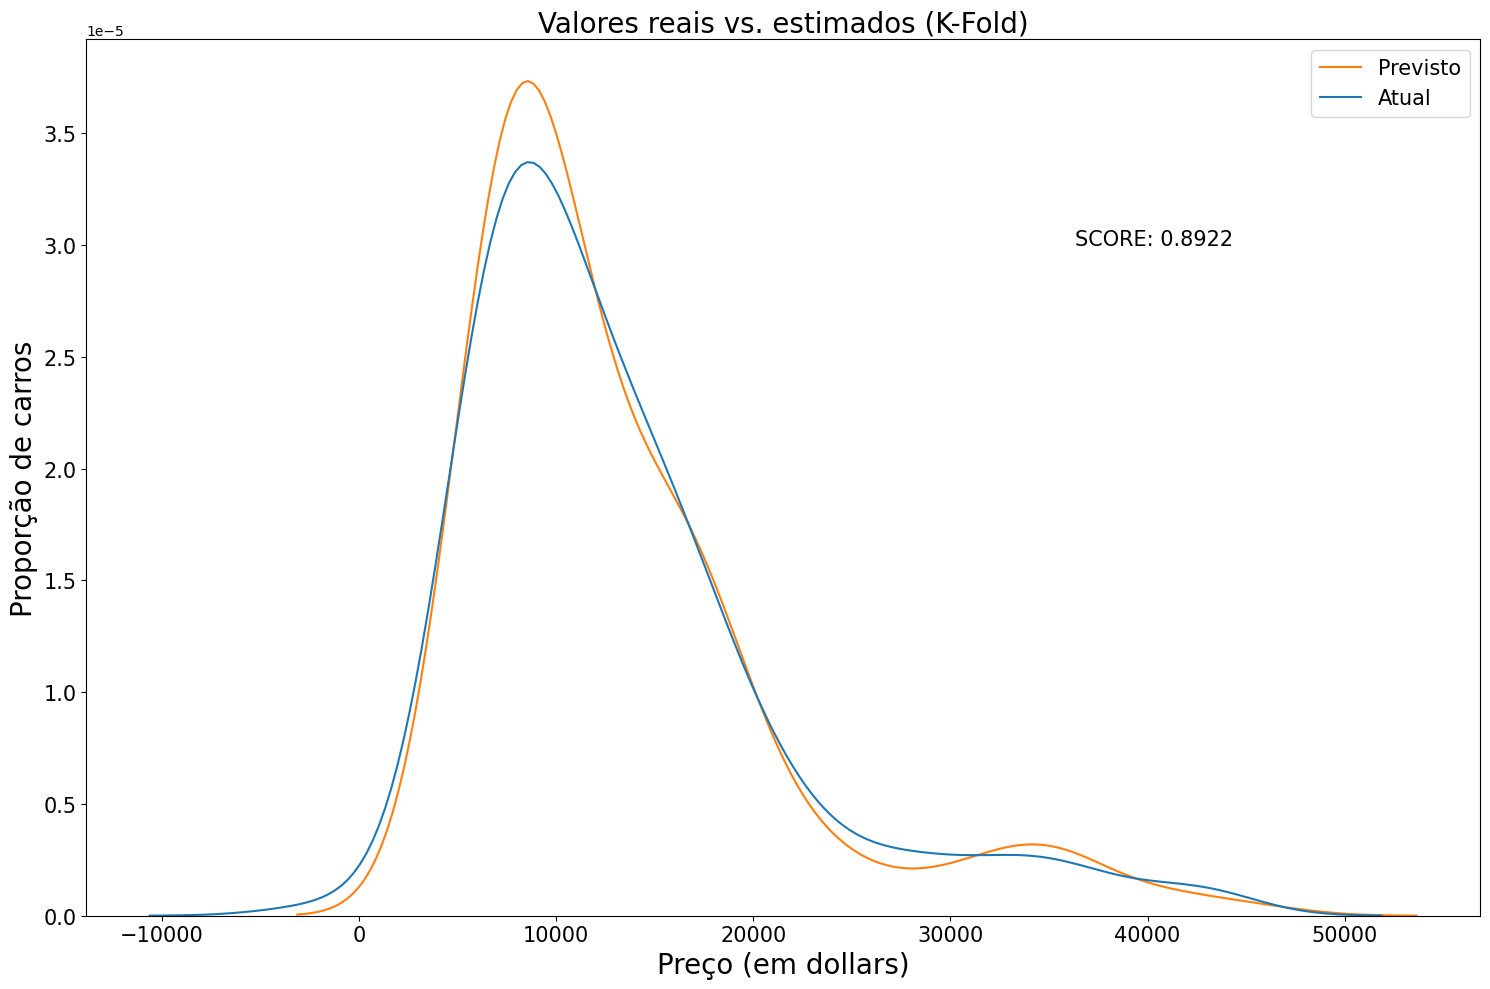

In [181]:
plt.figure(figsize=(15, 10))

# KDE Plot com valores acumulados dos folds
sns.kdeplot(data=[y_pred_all, y_true_all])

plt.title('Valores reais vs. estimados (K-Fold)', size=20)
plt.xlabel('Preço (em dollars)', size=20)
plt.ylabel('Proporção de carros', size=20)
plt.yticks(size=15)
plt.xticks(size=15)
plt.legend(labels=["Previsto", "Atual"], fontsize=15, bbox_to_anchor=(1, 1))

# Cálculo do R² total
R2 = r2_score(y_true_all, y_pred_all)
tt = "SCORE: %.4f" % R2

# Ajuste a posição do texto conforme sua escala
plt.text(max(y_true_all)*0.8, 0.00003, tt, size=15, color="black")

plt.tight_layout()
plt.show()

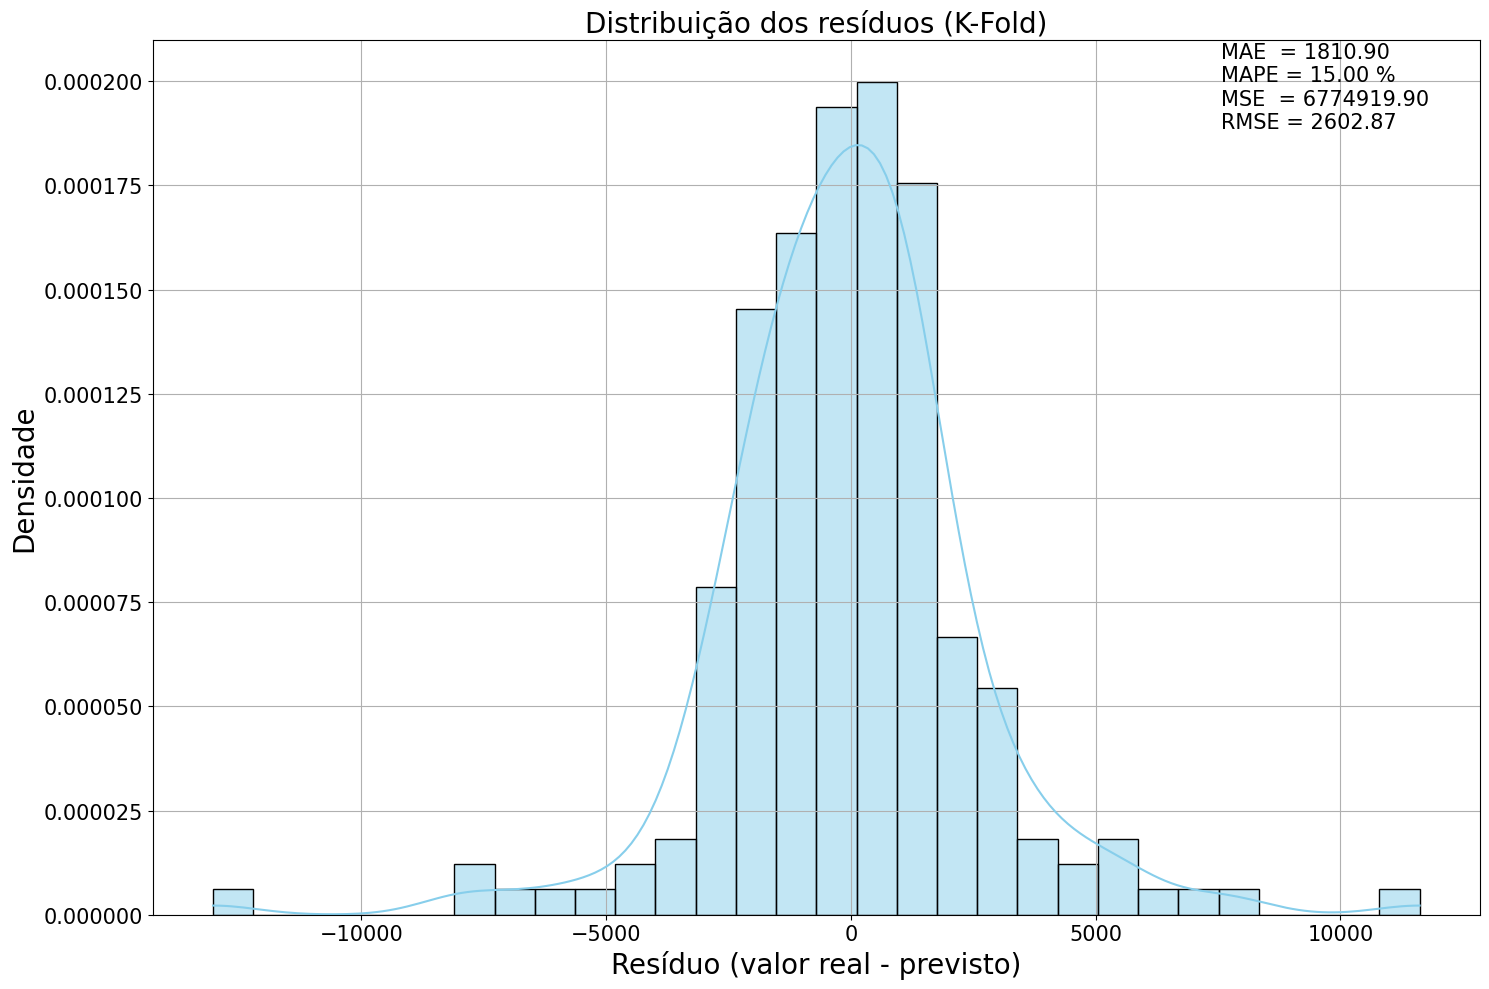

In [182]:
residuos = np.array(y_true_all) - np.array(y_pred_all)

mae = mean_absolute_error(y_true_all, y_pred_all)
mape = 100 * mean_absolute_percentage_error(y_true_all, y_pred_all)  # em %
mse = mean_squared_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)

tt = f"MAE  = {mae:.2f}\nMAPE = {mape:.2f} %\nMSE  = {mse:.2f}\nRMSE = {rmse:.2f}"

plt.figure(figsize=(15, 10))
sns.histplot(x=residuos, kde=True, stat="density", bins=30, color="skyblue", edgecolor="black")

plt.title("Distribuição dos resíduos (K-Fold)", size=20)
plt.xlabel('Resíduo (valor real - previsto)', size=20)
plt.ylabel('Densidade', size=20)
plt.xticks(size=15)
plt.yticks(size=15)
plt.grid(True)

plt.text(x=max(residuos)*0.65, y=plt.gca().get_ylim()[1]*0.9, s=tt, size=15, color="black")

plt.tight_layout()
plt.show()

# Conclusão

Ao invés de utilizar os modelos de teste e treino para montar uma única vez o processo de ajuste da função, é utilizado o kfold que monta N subgrupos de testes de validação conforme o split que for necessário

Manualmente é necessário calcular os valores de erros.

Da forma como eu montei o código, pode-se apenas ajustar os valores de split para testar variações dos ajustes e resíduos

## Referências:

Translated and inspired in the material developed by IBM:
<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2021-01-01" target="_blank">Joseph Santarcangelo</a>
<br>

Documentação da biblioteca <a href="https://pandas.pydata.org/docs/">Pandas</a>

Documentação da biblioteca <a href="https://seaborn.pydata.org/">Seaborn</a>

Documentação do biblioteca <a href="https://matplotlib.org/">Matplotlib</a>

Documentação do biblioteca <a href="https://numpy.org/devdocs/reference/index.html">Numpy</a>

## Fique Conectado

- [![YouTube](https://img.icons8.com/ios-filled/40/000000/youtube-play.png)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/ios-filled/40/000000/linkedin.png)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/ios-filled/40/000000/instagram-new.png)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!


## Autores

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>, <a href="https://www.linkedin.com/in/hesauhugocavalcanti/" target="_blank">Hesau Hugo</a> , <a href="https://www.linkedin.com/in/joão-gabriel-santin-botelho/" target="_blank">João Gabriel</a>

## Referências:

Traduzido e inspirado do material desenvolviedo pela IBM:
<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2021-01-01" target="_blank">Joseph Santarcangelo</a>
<br>

* Documentação da biblioteca <a href="https://pandas.pydata.org/docs/">Pandas</a>
* Documentação da biblioteca <a href="https://seaborn.pydata.org/">Seaborn</a>
* Documentação do biblioteca <a href="https://matplotlib.org/">Matplotlib</a>
* Documentação do biblioteca <a href="https://numpy.org/devdocs/reference/index.html">Numpy</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| -----------| ------- | ---------- | ---------------------------------- |
| 04-04-2021       | 1.0     | Eduardo Pecora    | Inicial               |
| 03-11-2021       | 1.1     | Eduardo Pecora    | Estrutura Aula        |
| 08-03-2022       | 1.2     | Eduardo Pecora    | GitHub                |
| 17-04-2023       | 1.3     | Hesau Hugo        | Reestruturação        |
| 18-09-2024       | 1.4     | João Gabriel      | Atualização           |